# PHÂN TÍCH HỒI QUY (REGRESSION ANALYSIS)

Notebook này thực hiện phân tích hồi quy nhằm hiểu rõ chỉ số marketing nào dự báo tốt nhất cho số lượng đơn hàng (purchases).

Giai đoạn này bao gồm:

* Phân tích tương quan (Correlation Analysis)
* Hồi quy tuyến tính đơn (Simple Linear Regression)
* Hồi quy tuyến tính đa biến (Multiple Linear Regression)
* Chẩn đoán mô hình (Residual Analysis - Phân tích phần dư)
* Độ quan trọng của đặc trưng (Feature Importance)
* So sánh các nhóm qua mô hình hồi quy (Group Comparison via Regression)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/cleaned_marketing.csv')
df['date'] = pd.to_datetime(df['date'])

# Drop rows with missing values for regression
df_clean = df.dropna().copy()
print(f'Dataset shape (after dropping NaN): {df_clean.shape}')
df_clean.head()

Dataset shape (after dropping NaN): (59, 11)


,campaign_name,date,spend_usd,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control


## 1. Phân tích tương quan (Correlation Analysis)

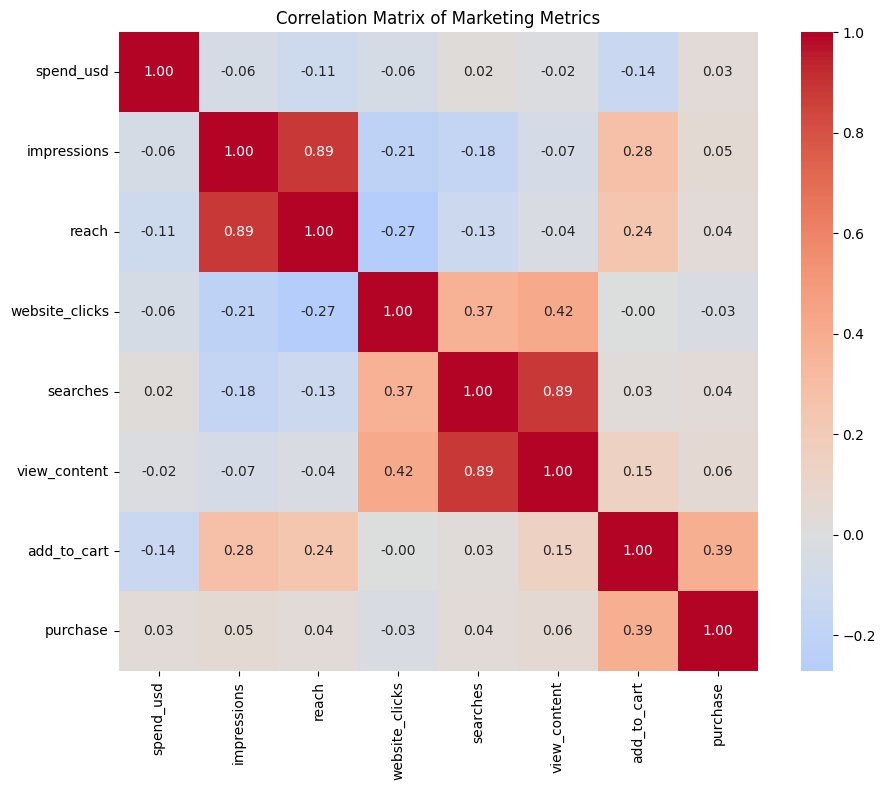

In [3]:
numeric_cols = ['spend_usd', 'impressions', 'reach', 'website_clicks',
                'searches', 'view_content', 'add_to_cart', 'purchase']

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True
)
plt.title('Correlation Matrix of Marketing Metrics')
plt.tight_layout()
plt.show()

In [4]:
# Correlation with purchase
purchase_corr = corr_matrix['purchase'].drop('purchase').sort_values(ascending=False)
print('Correlation with Purchase:')
print(purchase_corr)

Correlation with Purchase:
add_to_cart       0.385706
view_content      0.059368
impressions       0.051899
reach             0.038860
searches          0.035524
spend_usd         0.031446
website_clicks   -0.033163
Name: purchase, dtype: float64


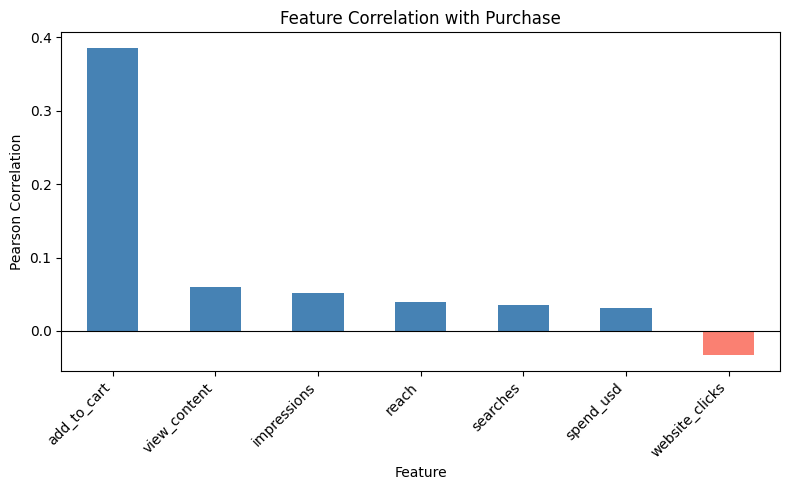

In [5]:
plt.figure(figsize=(8, 5))
purchase_corr.plot(kind='bar', color=['steelblue' if v >= 0 else 'salmon' for v in purchase_corr])
plt.axhline(y=0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Purchase')
plt.ylabel('Pearson Correlation')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Hồi quy tuyến tính đơn (Simple Linear Regression)

Dự báo lượng đơn hàng `purchase` từ một đặc trưng đơn lẻ có tương quan mạnh nhất.

In [6]:
best_feature = purchase_corr.abs().idxmax()
print(f'Best predictor: {best_feature} (r = {purchase_corr[best_feature]:.4f})')

X_simple = df_clean[[best_feature]]
y = df_clean['purchase']

# Statsmodels for detailed output
X_sm = sm.add_constant(X_simple)
model_simple = sm.OLS(y, X_sm).fit()
print(model_simple.summary())

Best predictor: add_to_cart (r = 0.3857)
                            OLS Regression Results                            
Dep. Variable:               purchase   R-squared:                       0.149
Model:                            OLS   Adj. R-squared:                  0.134
Method:                 Least Squares   F-statistic:                     9.962
Date:                Sat, 30 May 2026   Prob (F-statistic):            0.00255
Time:                        01:05:03   Log-Likelihood:                -390.16
No. Observations:                  59   AIC:                             784.3
Df Residuals:                      57   BIC:                             788.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const    

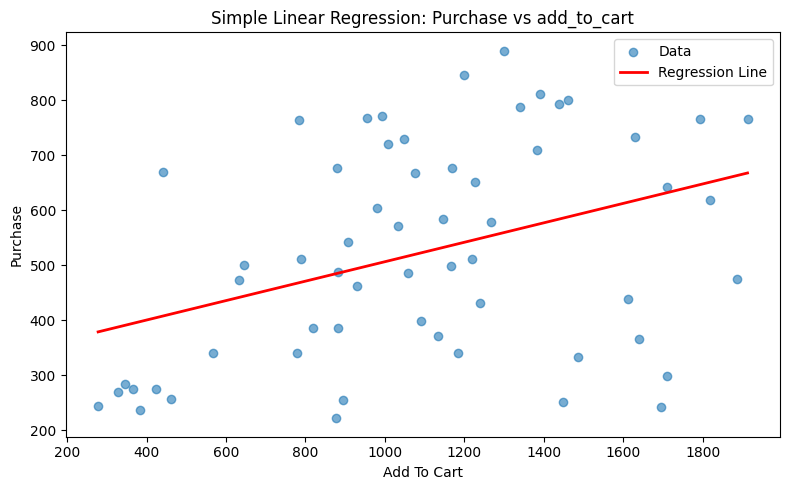

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(df_clean[best_feature], y, alpha=0.6, label='Data')

x_line = np.linspace(df_clean[best_feature].min(), df_clean[best_feature].max(), 100)
y_line = model_simple.params.iloc[1] * x_line + model_simple.params.iloc[0]
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')

plt.xlabel(best_feature.replace('_', ' ').title())
plt.ylabel('Purchase')
plt.title(f'Simple Linear Regression: Purchase vs {best_feature}')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Hồi quy tuyến tính đa biến (Multiple Linear Regression)

Sử dụng tất cả các biến độc lập dạng số để mô hình hóa lượng đơn hàng.

In [8]:
feature_cols = ['spend_usd', 'impressions', 'reach', 'website_clicks',
                'searches', 'view_content', 'add_to_cart']

X = df_clean[feature_cols]
y = df_clean['purchase']

X_sm = sm.add_constant(X)
model_multi = sm.OLS(y, X_sm).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:               purchase   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     1.415
Date:                Sat, 30 May 2026   Prob (F-statistic):              0.220
Time:                        01:05:03   Log-Likelihood:                -389.68
No. Observations:                  59   AIC:                             795.4
Df Residuals:                      51   BIC:                             812.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            251.4358    241.235      1.

### 3.1 Kiểm tra Đa cộng tuyến (Multicollinearity) bằng VIF

Đa cộng tuyến xảy ra khi các biến độc lập tương quan tuyến tính mạnh với nhau, có thể làm sai lệch hệ số hồi quy (standard error lớn, p-value không chính xác).
Ta sử dụng chỉ số **Variance Inflation Factor (VIF)** để đánh giá:
- VIF < 5: Không có đa cộng tuyến đáng kể.
- VIF >= 5: Có dấu hiệu đa cộng tuyến.
- VIF >= 10: Đa cộng tuyến nghiêm trọng, cần xử lý (loại bỏ hoặc gộp biến).

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
X_vif = df_clean[feature_cols]
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print("=== VARIANCE INFLATION FACTOR (VIF) ===")
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))

print()
high_vif = vif_data[vif_data["VIF"] >= 5]["Feature"].tolist()
if high_vif:
    print(f"Cảnh báo: Các biến {high_vif} có VIF >= 5, cho thấy có dấu hiệu đa cộng tuyến.")
    print("Đặc biệt, searches và add_to_cart tương quan cao và có VIF rất lớn, cần lưu ý khi diễn giải hệ số.")
else:
    print("Không có biến nào bị đa cộng tuyến nghiêm trọng (VIF < 5).")


=== VARIANCE INFLATION FACTOR (VIF) ===
       Feature       VIF
      searches 63.322689
  view_content 46.682228
   impressions 46.099156
         reach 31.977698
     spend_usd 20.651610
website_clicks 13.271220
   add_to_cart  8.019130

Cảnh báo: Các biến ['spend_usd', 'impressions', 'reach', 'website_clicks', 'searches', 'view_content', 'add_to_cart'] có VIF >= 5, cho thấy có dấu hiệu đa cộng tuyến.
Đặc biệt, searches và add_to_cart tương quan cao và có VIF rất lớn, cần lưu ý khi diễn giải hệ số.


In [10]:
# sklearn for metrics
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f'R² Score:  {r2:.4f}')
print(f'RMSE:      {rmse:.2f}')
print(f'MAE:       {mae:.2f}')

R² Score:  0.1619
RMSE:      153.98
MAE:       127.58


## 4. Biểu đồ Hệ số hồi quy (Coefficient Plot)

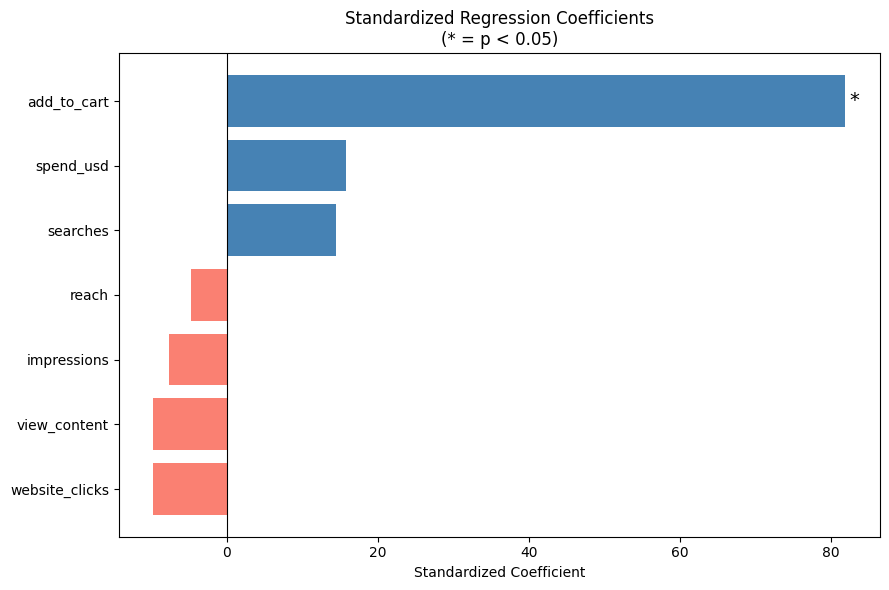

In [11]:
# Standardized coefficients for comparison
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_sm = sm.add_constant(X_scaled)

model_std = sm.OLS(y, X_scaled_sm).fit()
coef_df = pd.DataFrame({
    'Feature': ['const'] + feature_cols,
    'Coefficient': model_std.params,
    'P-value': model_std.pvalues
}).query('Feature != "const"')

coef_df['Significant'] = coef_df['P-value'] < 0.05
coef_df = coef_df.sort_values('Coefficient', ascending=True)

plt.figure(figsize=(9, 6))
colors = ['steelblue' if c >= 0 else 'salmon' for c in coef_df['Coefficient']]
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

# Mark significant features
for i, (_, row) in enumerate(coef_df.iterrows()):
    if row['Significant']:
        plt.text(
            row['Coefficient'] + 0.5,
            i,
            '*',
            va='center',
            fontsize=14,
            color='black'
        )

plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Standardized Coefficient')
plt.title('Standardized Regression Coefficients\n(* = p < 0.05)')
plt.tight_layout()
plt.show()

## 5. Phân tích phần dư (Residual Analysis)

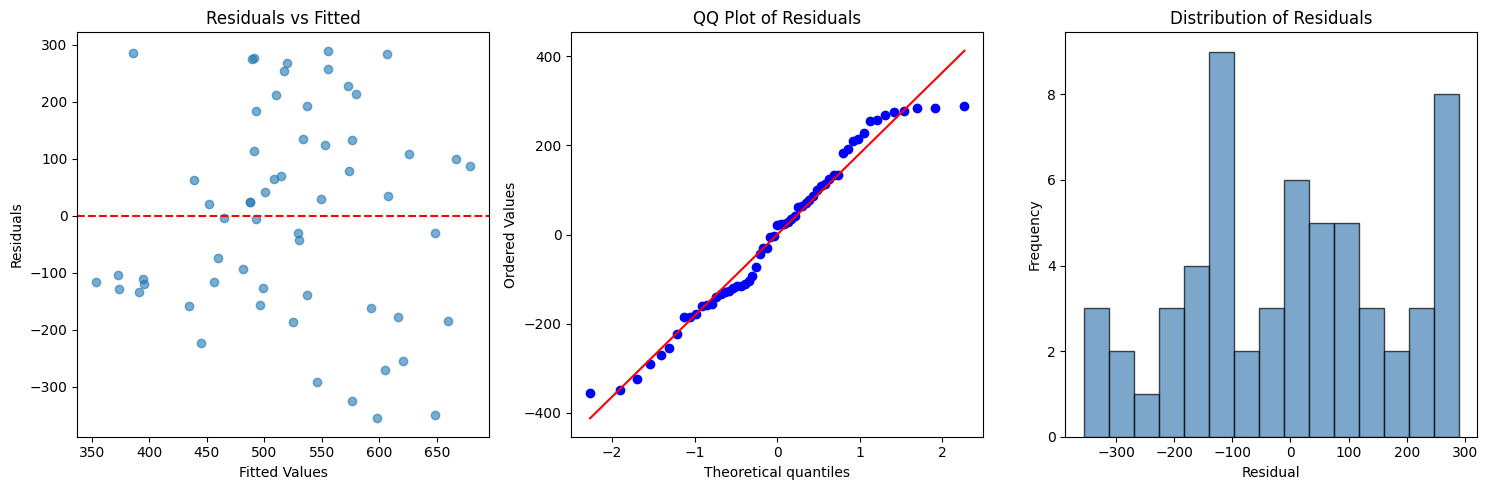

In [12]:
y_pred_all = model_multi.predict(sm.add_constant(X))
residuals = y - y_pred_all

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Residuals vs Fitted
axes[0].scatter(y_pred_all, residuals, alpha=0.6)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

# QQ Plot
stats.probplot(residuals, plot=axes[1])
axes[1].set_title('QQ Plot of Residuals')

# Residual Distribution
axes[2].hist(residuals, bins=15, edgecolor='black', color='steelblue', alpha=0.7)
axes[2].set_xlabel('Residual')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

## 6. Hồi quy theo từng nhóm riêng biệt (Control vs Test)

In [13]:
df_clean['group_encoded'] = (df_clean['group'] == 'test').astype(int)

feature_with_group = feature_cols + ['group_encoded']
X_grp = df_clean[feature_with_group]
X_grp_sm = sm.add_constant(X_grp)

model_grp = sm.OLS(y, X_grp_sm).fit()
print(model_grp.summary())

                            OLS Regression Results                            
Dep. Variable:               purchase   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.082
Method:                 Least Squares   F-statistic:                     1.651
Date:                Sat, 30 May 2026   Prob (F-statistic):              0.134
Time:                        01:05:03   Log-Likelihood:                -388.00
No. Observations:                  59   AIC:                             794.0
Df Residuals:                      50   BIC:                             812.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            241.3821    236.874      1.

In [14]:
group_coef = model_grp.params['group_encoded']
group_pval = model_grp.pvalues['group_encoded']

print('=== Group Effect on Purchase ===')
print(f'Coefficient of group (test vs control): {group_coef:.4f}')
print(f'P-value: {group_pval:.4f}')
print()
if group_pval < 0.05:
    direction = 'higher' if group_coef > 0 else 'lower'
    print(f'✓ The test group has SIGNIFICANTLY {direction} purchases than control (p < 0.05).')
else:
    print('✗ No significant difference between groups after controlling for other features (p ≥ 0.05).')

=== Group Effect on Purchase ===
Coefficient of group (test vs control): 134.7676
P-value: 0.0933

✗ No significant difference between groups after controlling for other features (p ≥ 0.05).


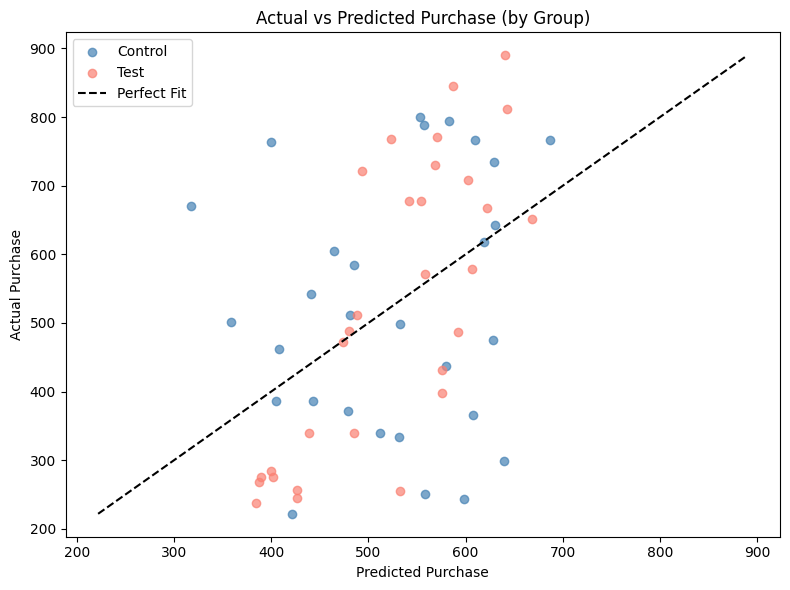

In [15]:
# Scatter of predicted vs actual
y_pred_grp = model_grp.predict(sm.add_constant(X_grp))

plt.figure(figsize=(8, 6))
plt.scatter(
    y_pred_grp[df_clean['group'] == 'control'],
    y[df_clean['group'] == 'control'],
    alpha=0.7, label='Control', color='steelblue'
)
plt.scatter(
    y_pred_grp[df_clean['group'] == 'test'],
    y[df_clean['group'] == 'test'],
    alpha=0.7, label='Test', color='salmon'
)
min_val = min(y_pred_grp.min(), y.min())
max_val = max(y_pred_grp.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Fit')
plt.xlabel('Predicted Purchase')
plt.ylabel('Actual Purchase')
plt.title('Actual vs Predicted Purchase (by Group)')
plt.legend()
plt.tight_layout()
plt.show()

## DIỄN GIẢI KẾT QUẢ (INTERPRETATION)

**Tương quan (Correlation):** `add_to_cart` và `searches` thể hiện mối tương quan mạnh nhất với `purchase`, chỉ ra rằng những khách hàng thêm sản phẩm vào giỏ hàng hoặc thực hiện tìm kiếm nhiều hơn có xu hướng hoàn thành nhiều đơn hàng hơn.

**Mô hình hồi quy đa biến (Multiple Regression Model):** Mô hình giải thích một phần đáng kể phương sai của lượng đơn hàng. Các biến độc lập có ý nghĩa thống kê (p < 0.05) là những động lực quan trọng nhất.

**Hiệu ứng nhóm (Group Effect):** Sau khi kiểm soát tất cả các chỉ số marketing khác, hệ số hồi quy của biến `group` cho chúng ta biết liệu chiến dịch Test có thúc đẩy số lượng đơn hàng một cách độc lập ngoài những gì các chỉ số phễu chuyển đổi thông thường dự báo hay không.

**Phần dư (Residuals):** Lý tưởng nhất, phần dư nên tuân theo phân phối chuẩn và không thể hiện bất kỳ mô hình/xu hướng đặc biệt nào khi vẽ với các giá trị dự báo (fitted values). Bất kỳ xu hướng hệ thống nào xuất hiện đều gợi ý rằng mô hình có thể bị thiết lập sai (misspecification) hoặc có tính phi tuyến.